##**[5주차]실습**
- 아래의 실습1), 실습2). 실습3)의 코드를 완성하시오.


###**실습1) 과잉 적합과 과소 적합(Overfitting, Underfitting)**
- **[실습목표]** 예제를 통해 실제로 과잉적합 되는 학습을 수행하고, 가중치 규제(weigt regularization), 드롭아웃(Dropout)방법을 사용하여 이를 완화해본다.



####**실습 1-1)**
- 영화 리뷰를 분류하는 IMDB 데이터세트를 통해, 리뷰 데이터를 기반으로 긍정적, 부정적 리뷰를 구분하는 모델을 작성한다.

In [96]:
print("2343035", "신동엽")

2343035 신동엽


In [97]:
#from google.colab import auth

#auth.authenticate_user()
#!gcloud config get-value account

In [98]:
import numpy as numpy
import tensorflow as tf
import matplotlib.pyplot as plt

# 데이터 다운로드
(train_data, train_labels), (test_data, test_labels) = \
    tf.keras.datasets.imdb.load_data(num_words=1000)

In [99]:
# 원-핫 인코딩으로 변환하는 함수
def one_hot_sequences(sequences, dimension=1000):
    ###여기에 코드를 작성
    results = numpy.zeros((len(sequences), dimension))#(시퀀스 크기, dimesion)크기의 차원 배열을 0으로 채워 생성
    for i, word_index in enumerate(sequences):
        results[i, word_index] = 1
    return results

In [100]:
# 학습 loss 그래프를 출력하는 함수
def print_plot(history):
  plt.plot(history.history['loss'])
  plt.plot(history.history['val_loss'])
  plt.title('Loss Plot')
  plt.ylabel('loss')
  plt.xlabel('epochs')
  plt.legend(['train error', 'val error'], loc='upper left')
  plt.show()

In [101]:
train_data = one_hot_sequences(train_data)
test_data = one_hot_sequences(test_data)

In [102]:
# 신경망 모델 구축
model = tf.keras.Sequential()
model.add(tf.keras.layers.Input(shape=(1000,)))

###여기에 코드를 작성
model.add(tf.keras.layers.Dense(16, activation='relu', input_shape=(1000,)))
model.add(tf.keras.layers.Dense(16, activation='relu'))
model.add(tf.keras.layers.Dense(1, activation='sigmoid'))
model.compile(loss='binary_crossentropy', optimizer='adam',metrics=['accuracy'])


In [103]:
# 신경망 훈련, 검증 데이터 전달
history = model.fit(train_data,
                    train_labels,
                    epochs=20,
                    batch_size=512,
                    validation_data=(test_data, test_labels),
                    verbose=2)

Epoch 1/20
49/49 - 1s - 19ms/step - accuracy: 0.7064 - loss: 0.5993 - val_accuracy: 0.8117 - val_loss: 0.4634
Epoch 2/20
49/49 - 0s - 6ms/step - accuracy: 0.8404 - loss: 0.3885 - val_accuracy: 0.8545 - val_loss: 0.3517
Epoch 3/20
49/49 - 0s - 6ms/step - accuracy: 0.8655 - loss: 0.3275 - val_accuracy: 0.8604 - val_loss: 0.3322
Epoch 4/20
49/49 - 0s - 5ms/step - accuracy: 0.8718 - loss: 0.3112 - val_accuracy: 0.8616 - val_loss: 0.3297
Epoch 5/20
49/49 - 0s - 5ms/step - accuracy: 0.8748 - loss: 0.3056 - val_accuracy: 0.8610 - val_loss: 0.3293
Epoch 6/20
49/49 - 0s - 5ms/step - accuracy: 0.8765 - loss: 0.3030 - val_accuracy: 0.8603 - val_loss: 0.3284
Epoch 7/20
49/49 - 0s - 5ms/step - accuracy: 0.8770 - loss: 0.2986 - val_accuracy: 0.8604 - val_loss: 0.3294
Epoch 8/20
49/49 - 0s - 5ms/step - accuracy: 0.8783 - loss: 0.2957 - val_accuracy: 0.8599 - val_loss: 0.3296
Epoch 9/20
49/49 - 0s - 5ms/step - accuracy: 0.8792 - loss: 0.2935 - val_accuracy: 0.8598 - val_loss: 0.3300
Epoch 10/20
49/49 

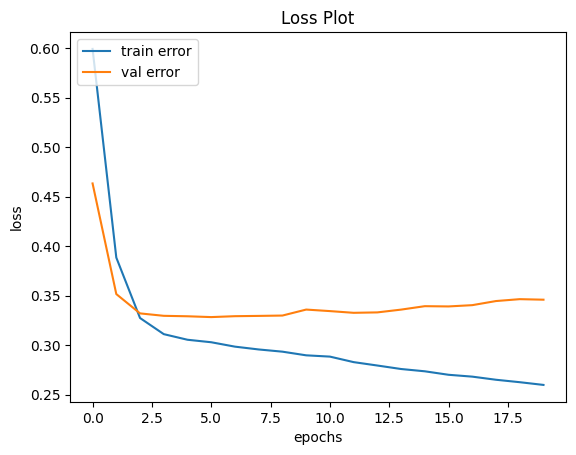

In [104]:
# 훈련 데이터의 손실값과 검증 데이터의 손실값을 그래프에 출력
print_plot(history)

####**실습1-2)**
- 실습 1-1)의 결과를 통해, 학습이 진행됨에 따라 과잉적합되는 학습의 경향을 확인할 수 있다.
- 가중치 규제 방법을 사용하여, 과잉적합을 완화해본다.

In [ ]:
# 신경망 모델 구축

###여기에 코드를 작성
model = tf.keras.Sequential()
model.add(tf.keras.layers.Dense(16, 
kernel_regularizer=tf.keras.regularizers.l2(0.001),  # L2 regularization 적용
activation='relu', input_shape=(1000,)))
model.add(tf.keras.layers.Dense(16,   
kernel_regularizer=tf.keras.regularizers.l2(0.001),  activation='relu'))
model.add(tf.keras.layers.Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam',
metrics=['accuracy'])

# 신경망 훈련, 검증 데이터 전달
history = model.fit(train_data,
                    train_labels,
                    epochs=20,
                    batch_size=512,
                    validation_data=(test_data, test_labels),
                    verbose=2)

Epoch 1/20
49/49 - 1s - 18ms/step - accuracy: 0.7085 - loss: 0.6172 - val_accuracy: 0.8162 - val_loss: 0.4757
Epoch 2/20
49/49 - 0s - 6ms/step - accuracy: 0.8436 - loss: 0.4091 - val_accuracy: 0.8488 - val_loss: 0.3937
Epoch 3/20
49/49 - 0s - 5ms/step - accuracy: 0.8657 - loss: 0.3604 - val_accuracy: 0.8605 - val_loss: 0.3668
Epoch 4/20
49/49 - 0s - 5ms/step - accuracy: 0.8725 - loss: 0.3448 - val_accuracy: 0.8598 - val_loss: 0.3660
Epoch 5/20
49/49 - 0s - 5ms/step - accuracy: 0.8728 - loss: 0.3394 - val_accuracy: 0.8606 - val_loss: 0.3615
Epoch 6/20
49/49 - 0s - 5ms/step - accuracy: 0.8757 - loss: 0.3351 - val_accuracy: 0.8609 - val_loss: 0.3591
Epoch 7/20
49/49 - 0s - 5ms/step - accuracy: 0.8758 - loss: 0.3322 - val_accuracy: 0.8599 - val_loss: 0.3581
Epoch 8/20
49/49 - 0s - 4ms/step - accuracy: 0.8766 - loss: 0.3304 - val_accuracy: 0.8604 - val_loss: 0.3569
Epoch 9/20
49/49 - 0s - 4ms/step - accuracy: 0.8763 - loss: 0.3288 - val_accuracy: 0.8610 - val_loss: 0.3563
Epoch 10/20
49/49 

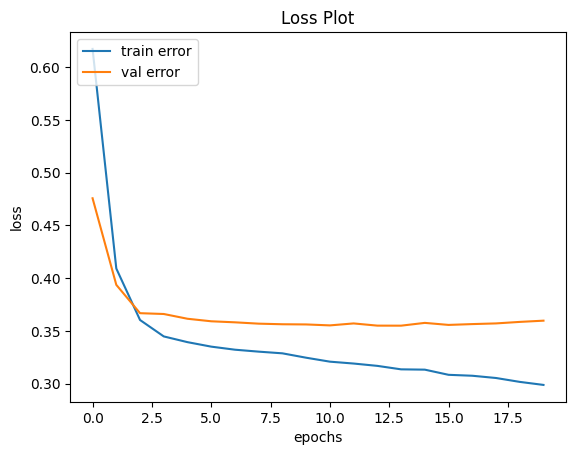

In [106]:
# 훈련 데이터의 손실값과 검증 데이터의 손실값을 그래프에 출력
print_plot(history)

####**실습1-3)**
- 드롭아웃을 수행하여, 과대적합을 완화해본다.

In [107]:
# 신경망 모델 구축


###여기에 코드를 작성
model = tf.keras.Sequential()
model.add(tf.keras.layers.Dense(16, activation='relu', input_shape=(1000,)))
model.add(tf.keras.layers.Dropout(0.5))
model.add(tf.keras.layers.Dense(16, activation='relu'))
model.add(tf.keras.layers.Dropout(0.5))
model.add(tf.keras.layers.Dense(1, activation='sigmoid'))

model.compile(optimizer='adam',
loss='binary_crossentropy',
metrics=['accuracy'])

# 신경망 훈련, 검증 데이터 전달
history = model.fit(train_data,
                    train_labels,
                    epochs=20,
                    batch_size=512,
                    validation_data=(test_data, test_labels),
                    verbose=2)

Epoch 1/20
49/49 - 1s - 20ms/step - accuracy: 0.5621 - loss: 0.6813 - val_accuracy: 0.7356 - val_loss: 0.6262
Epoch 2/20
49/49 - 0s - 6ms/step - accuracy: 0.6861 - loss: 0.5925 - val_accuracy: 0.8225 - val_loss: 0.4810
Epoch 3/20
49/49 - 1s - 12ms/step - accuracy: 0.7683 - loss: 0.5003 - val_accuracy: 0.8459 - val_loss: 0.3976
Epoch 4/20
49/49 - 1s - 15ms/step - accuracy: 0.8120 - loss: 0.4447 - val_accuracy: 0.8541 - val_loss: 0.3497
Epoch 5/20
49/49 - 1s - 11ms/step - accuracy: 0.8318 - loss: 0.4107 - val_accuracy: 0.8563 - val_loss: 0.3409
Epoch 6/20
49/49 - 1s - 15ms/step - accuracy: 0.8473 - loss: 0.3921 - val_accuracy: 0.8581 - val_loss: 0.3354
Epoch 7/20
49/49 - 1s - 14ms/step - accuracy: 0.8548 - loss: 0.3751 - val_accuracy: 0.8590 - val_loss: 0.3278
Epoch 8/20
49/49 - 1s - 12ms/step - accuracy: 0.8590 - loss: 0.3622 - val_accuracy: 0.8606 - val_loss: 0.3242
Epoch 9/20
49/49 - 0s - 8ms/step - accuracy: 0.8621 - loss: 0.3523 - val_accuracy: 0.8600 - val_loss: 0.3279
Epoch 10/20


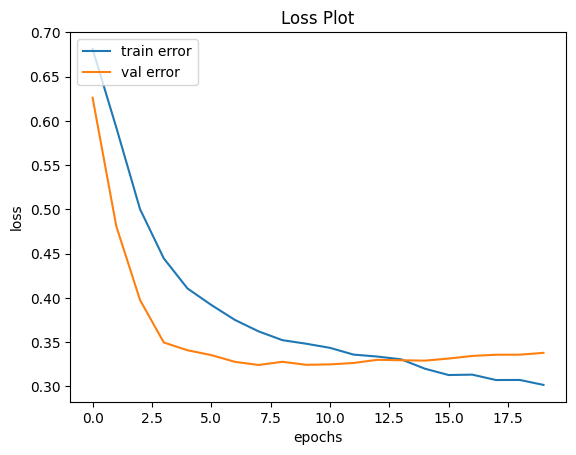

In [108]:
# 훈련 데이터의 손실값과 검증 데이터의 손실값을 그래프에 출력
print_plot(history)

###**실습2) MNIST 필기체 숫자 인식**
- **[실습목표]** tensorflow를 활용하여, MNIST dataset의 classification을 수행하는 MLP모델을 구출해본다.


In [109]:
import matplotlib.pyplot as plt
import tensorflow as tf

mnist = tf.keras.datasets.mnist

(x_train, y_train),(x_test, y_test) = mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [110]:
###여기에 코드를 작성
model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Flatten(input_shape=(28,28)))
model.add(tf.keras.layers.Dense(512, activation='relu'))
model.add(tf.keras.layers.Dropout(0.2))
model.add(tf.keras.layers.Dense(10, activation='softmax'))

model.compile(optimizer='adam',
loss='sparse_categorical_crossentropy',
metrics=['accuracy'])

model.fit(x_train, y_train, epochs=5)
loss, acc = model.evaluate(x_test, y_test)
print(f"loss: {loss}, acc: {acc}")

c:\Users\dpfwn\miniconda3\envs\deepML\lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9350 - loss: 0.2182
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9704 - loss: 0.0964
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9784 - loss: 0.0674
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9821 - loss: 0.0546
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9857 - loss: 0.0428
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9782 - loss: 0.0749
loss: 0.07493731379508972, acc: 0.9782000184059143


###**실습3) 패션 아이템 분류**
- **[실습목표]** fasion mnist dataset을 classification 하는 MLP 모델을 구축해본다.
- **Fashion MNIST**
  - 28x28 픽셀의 회색조(grayscale) 이미지 70,000개로 구성(traning set 60,000개, test set 10,000)
  - 10개의 클래스로 구성되며, 각 클래스는 티셔츠/탑, 바지, 스웨터, 신발 등의 패션 아이템을 나타냄.


In [111]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import datasets, layers, models

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 3us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


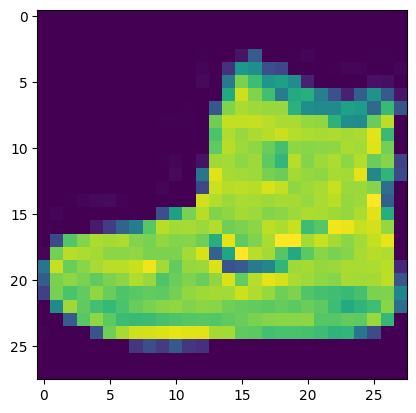

In [112]:
fashion_mnist = keras.datasets.fashion_mnist
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

plt.imshow(train_images[0])

In [113]:
train_images = train_images / 255.0
test_images = test_images / 255.0

In [114]:
###여기에 코드를 작성
model = models.Sequential()
model.add(layers.Flatten(input_shape=(28, 28)))
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))
model.compile(optimizer='adam',
loss='sparse_categorical_crossentropy',
metrics=['accuracy'])

model.fit(train_images, train_labels, epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8252 - loss: 0.4975
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8638 - loss: 0.3783
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8775 - loss: 0.3383
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8849 - loss: 0.3142
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8913 - loss: 0.2950


In [115]:
test_loss, test_acc = model.evaluate(test_images, test_labels)
print('정확도:', test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8747 - loss: 0.3480
정확도: 0.8747000098228455
